<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB36 · Ángulos y giros: dónde está el pie

**Parte 5 · La física del cuerpo — Lección 1**

> En el **NB35** Hopper aprendió a saltar a casi 10 km/h y Walker2d a andar "cayéndose hacia delante". Lo hicieron sin saber nada de física: un millón de intentos y una recompensa.

Con eso cerramos la Parte 4. Empieza la **Parte 5 · La física del cuerpo**. ¿Para qué, si el RL ya aprende solo?

Porque un ingeniero de robots que **solo** sabe lanzar entrenamientos está a ciegas. Cuando el robot se cae, hay que saber **por qué**. Cuando la recompensa necesita un término como "levanta el pie 10 cm" (el *reward shaping* del NB35), hay que saber **calcular** dónde está el pie. Cuando el robot pase al mundo real, habrá que entender sus motores y sus sensores. Y cuando quieras diseñar **tu propio** robot, tendrás que describir su cuerpo pieza a pieza.

Todo eso descansa en un poco de física y en unas matemáticas que aún no hemos visto. Hoy empezamos por la más básica de todas: los **ángulos**.

Mira lo que observaba Hopper (NB35): la altura del torso... y luego **ángulos**: el de la cadera, el de la rodilla, el del tobillo. El robot no sabe **dónde** tiene el pie. Solo sabe **cuánto** tiene girada cada articulación. Pasar de "cuánto está girada cada articulación" a "dónde está el pie" es la pregunta de hoy. Al final del notebook la responderás con una fórmula tuya y la comprobarás contra el simulador de verdad.


## 1 · ¿Qué es un ángulo?

Un **ángulo** mide **cuánto ha girado** algo. Abre una puerta: al principio está cerrada, pegada a la pared; la empujas y gira sobre sus bisagras. "Cuánto la has abierto" es un ángulo.

```
   pared                    pared
   ═════╗                   ═════╗
        ║ puerta                 ║ ╲
        ║ (cerrada)              ║   ╲  puerta
        ║                        ║     ╲  (abierta)
        ●  bisagra               ●───────
                                   ángulo
```

Fíjate en que un ángulo siempre necesita **dos cosas**:

1. **Un punto fijo** alrededor del cual se gira (la bisagra). En un robot, es la **articulación**.
2. **Una posición de partida** desde la que se mide (la puerta cerrada). Es el "cero" del ángulo.

Y no importa lo **larga** que sea la puerta: una puerta pequeña y una puerta enorme abiertas "lo mismo" tienen el mismo ángulo. El ángulo mide el **giro**, no la distancia.

En el cuerpo del robot (NB01), cada **bisagra** tiene su ángulo: el de la rodilla dice cuánto está doblada; el de la cadera, cuánto está adelantada o atrasada la pierna.


## 2 · Medir ángulos en grados

La forma de medir ángulos que seguramente conoces son los **grados** (°). Una **vuelta entera** son **360°**:

```
                  90°
                   │
                   │
     180° ─────────●───────── 0°   (y 360°: has dado la vuelta entera)
                   │
                   │
                  270°
```

- **0°**: no has girado nada.
- **90°**: un cuarto de vuelta, una **esquina** (un "ángulo recto", como el de una hoja de papel).
- **180°**: media vuelta, mirar hacia atrás.
- **360°**: la vuelta entera; estás otra vez como al principio.

¿Por qué 360 y no 100? Por los **babilonios**, hace más de 4.000 años. Contaban en grupos de 60 (también de ahí vienen los 60 minutos de una hora) y 360 es un número comodísimo: se puede dividir entre 2, 3, 4, 5, 6, 8, 9, 10, 12... sin decimales. Una costumbre muy antigua que hemos heredado, nada más.


## 3 · El número π

Para entender la otra forma de medir ángulos necesitamos conocer a un número famosísimo.

Coge cualquier cosa redonda: un vaso, una rueda, una pizza. Mide **cuánto mide su borde** (dándole la vuelta con un hilo, por ejemplo); eso se llama **perímetro** o **circunferencia**. Mide también **lo ancho que es** (de lado a lado, pasando por el centro): eso es el **diámetro**. Ahora divide:

```
   perímetro ÷ diámetro  =  3,14159...
```

Da **siempre lo mismo**, sea un vaso o la rueda de un camión: un poco más de **3**. A ese número se le llama **π** (la letra griega "pi"). Tiene infinitos decimales sin repetirse, pero con **3,14** basta para casi todo.

Dicho al revés: el borde de un círculo mide **π veces su diámetro**. Y como el diámetro es dos veces el **radio** (la distancia del centro al borde):

```
   perímetro  =  π × diámetro  =  2 × π × radio
```

Python ya conoce π. Está en el módulo `math` (NB26):


In [1]:
import math

print(math.pi)

3.141592653589793


Y comprobemos la fórmula con una rueda de robot de **10 cm de radio** (0,1 m): ¿cuánto avanza en una vuelta completa?

In [2]:
radio = 0.1
perimetro = 2 * math.pi * radio
print(round(perimetro, 3), "metros por vuelta")

0.628 metros por vuelta


Unos **63 centímetros** por vuelta. Si la rueda no resbala, eso es lo que avanza el robot cada vez que la rueda da una vuelta completa.


## 4 · Medir ángulos en radianes

Ahora sí, la otra forma de medir ángulos: los **radianes**. Es la que usan **todos** los simuladores (MuJoCo incluido), todas las librerías de matemáticas y todos los ingenieros. Te la prometí en el NB24.

La idea es preciosa. En vez de inventarse un número como 360, mide el ángulo **con el propio radio**:

> Coge un trozo de cuerda **tan largo como el radio** del círculo. Pégalo **sobre el borde** del círculo. El ángulo que abarca, visto desde el centro, es **1 radián**.

```
               ·  ·  ·
           ·     ╱      ·   ← este trozo del borde mide lo mismo que el radio
         ·     ╱          ·
        ·    ╱  1 radián   ·
        ·  ●───────────────·
              radio
```

¿Cuántos radianes tiene una vuelta entera? Pues cuántos trozos de cuerda (de largo "un radio") caben alrededor del borde. El borde mide **2 × π × radio**, así que caben **2 × π** trozos:

```
   una vuelta entera  =  360°  =  2π radianes  ≈  6,28 radianes
   media vuelta       =  180°  =   π radianes  ≈  3,14 radianes
   un cuarto de vuelta =  90°  =  π/2 radianes ≈  1,57 radianes
```

¿Y cuántos grados es **1 radián**? 360 entre 6,28: unos **57,3°**. Un ángulo bastante abierto.


In [3]:
print(360 / (2 * math.pi), "grados en 1 radián")

57.29577951308232 grados en 1 radián


### ¿Por qué complicarse con radianes?

Porque con radianes **muchas fórmulas se vuelven sencillísimas**. La más importante: si un punto está a una distancia **r** del centro y gira un ángulo **θ** (la letra griega "theta", que se pronuncia "zeta" en español y es la que se usa casi siempre para los ángulos) en radianes, recorre un trozo de borde (un **arco**) de largo:

```
   arco  =  r × θ
```

Sin más. En grados haría falta una fórmula con 360 y π por medio. Comprobémoslo con la rueda: una vuelta son 2π radianes, así que el arco es 0,1 × 2π, los mismos 0,63 m de antes:


In [4]:
theta = 2 * math.pi             # una vuelta entera, en radianes
print(round(radio * theta, 3), "metros")

0.628 metros


Esto sirve muchísimo en robots: si la cadera de Walker2d gira **0,3 radianes** y la pierna mide **1 metro**, el pie se mueve un arco de **0,3 metros**. Directo.


### Pasar de unos a otros

Python trae dos funciones para traducir: `math.radians` (de grados a radianes) y `math.degrees` (de radianes a grados). Una cada vez:

In [5]:
print(math.radians(90))

1.5707963267948966


90° son 1,5708 radianes: π/2, como en la tabla. Y al revés:

In [6]:
print(math.degrees(math.pi))

180.0


π radianes son 180°: media vuelta. Ahora podemos entender dos números del NB35:

In [7]:
print("Hopper:  ", round(math.degrees(0.2), 1), "grados")
print("Walker2d:", round(math.degrees(1.0), 1), "grados")

Hopper:   11.5 grados
Walker2d: 57.3 grados


Hopper se considera "caído" si su torso se inclina más de **0,2 radianes**: unos **11°**, muy poquito. Walker2d puede inclinarse hasta **1 radián**: unos **57°**, ¡más de media esquina! Por eso Walker2d podía andar tan inclinado hacia delante en el GIF del NB35.


### El signo del ángulo

Un ángulo también puede ser **negativo** (los números negativos los vimos en el NB03). El signo dice **hacia qué lado** se gira. La costumbre de los matemáticos es:

- **positivo**: en contra de las agujas del reloj (↺);
- **negativo**: a favor de las agujas del reloj (↻).

Pero cada robot decide su propio "hacia dónde es positivo" para cada articulación. En el Hopper de MuJoCo, por ejemplo, la rodilla solo puede ir de **−150°** a **0°**: solo se dobla **hacia un lado**, como tu rodilla. Lo importante es **mirar** en cada robot qué significa el signo, y no darlo por supuesto. Lo comprobaremos en la sección 10.


## 5 · El seno y el coseno: las sombras de un punto que gira

Llegamos al corazón del notebook. Dos funciones matemáticas que asustan por el nombre, pero que vas a entender con una **linterna**.

Imagina un **reloj de un solo brazo**, de largo **1**, que puede girar alrededor del centro. Su punta es un punto que se mueve por un círculo de radio 1. El brazo empieza apuntando a la **derecha** (ángulo 0) y gira un ángulo θ en contra de las agujas del reloj.

Ahora encendemos **dos linternas**:

- Una **desde arriba**, apuntando hacia abajo. La punta del brazo proyecta una **sombra en el suelo** (en la línea horizontal). Lo que mide esa sombra, desde el centro, se llama **coseno** de θ, y se escribe **cos θ**.
- Otra **desde la derecha**, apuntando a la izquierda. La punta proyecta una **sombra en la pared** (en la línea vertical). Lo que mide esa sombra se llama **seno** de θ: **sin θ** (del latín *sinus*).

```
              pared
                │
     sin θ  ────┼ · · · · ●  ← punta del brazo
     (sombra    │       ╱ │
     en la      │     ╱   │
     pared)     │   ╱ θ   │
                ●─────────┼──────  suelo
                    cos θ
                (sombra en el suelo)
```

En otras palabras: **cos θ es "cuánto a la derecha"** está la punta, y **sin θ es "cuánto hacia arriba"**. Son las dos **coordenadas** (NB12) de la punta del brazo.


Pensemos unos cuantos casos **sin calcular nada**, solo imaginando el brazo:

| Ángulo | Dónde está la punta | cos θ (derecha) | sin θ (arriba) |
|---|---|---|---|
| 0° | a la derecha del todo | 1 | 0 |
| 90° | arriba del todo | 0 | 1 |
| 180° | a la izquierda del todo | −1 | 0 |
| 270° | abajo del todo | 0 | −1 |

Por ejemplo, a 90° el brazo apunta hacia arriba: su sombra en el suelo es un **puntito** (cos = 0) y su sombra en la pared es **todo el brazo** (sin = 1). Y a 180° apunta a la izquierda: la sombra en el suelo mide 1, pero hacia la **izquierda**, así que vale **−1**.

Y a 45°, justo a medio camino entre la derecha y arriba, las dos sombras son **iguales**. ¿Cuánto miden? Ahora sí, que lo calcule Python.


### Seno y coseno en Python

Están en `math`: `math.sin` y `math.cos`. **Ojo: quieren el ángulo en radianes.** Primero lo traducimos:

In [8]:
angulo = math.radians(45)
print(math.cos(angulo))

0.7071067811865476


In [9]:
print(math.sin(angulo))

0.7071067811865475


Iguales, como predijimos: **0,7071** (salen 0,7071067811865476 y 0,7071067811865475: el último decimal distinto es el "ruido de decimales" del NB06). Y no son 0,5, como quizá esperabas: la punta está a distancia 1 del centro, pero en **diagonal**, y en diagonal se llega "más lejos" con menos derecha y menos arriba.

Ahora la **trampa** en la que cae todo el mundo, al menos una vez. ¿Cuál es el seno de 90°? Por la tabla, **1**. Pero mira lo que pasa si le das los grados directamente:


In [10]:
print(math.sin(90))

0.8939966636005579


**0,894**. ¡Ni error ni aviso! Python ha entendido "90 **radianes**" (que son más de 14 vueltas) y ha calculado su seno, sin rechistar. Es de los fallos más traicioneros: el programa funciona, pero da números equivocados. Por eso, siempre que veas un ángulo, pregúntate **en qué unidades** está. Bien hecho:


In [11]:
print(math.sin(math.radians(90)))

1.0


### Las ondas

¿Qué pasa con las sombras si el brazo **gira sin parar**? Calculemos el seno y el coseno para muchos ángulos, de 0 a dos vueltas, y dibujémoslos. Primero la lista de ángulos, con NumPy (NB15), que tiene su propio `np.sin` y `np.cos` que funcionan con listas enteras de golpe:


In [12]:
import numpy as np
import matplotlib.pyplot as plt

angulos = np.linspace(0, 4 * np.pi, 200)     # 200 ángulos repartidos entre 0 y dos vueltas
print(angulos[:4].round(3), "...", angulos[-1].round(3))

[0.    0.063 0.126 0.189] ... 12.566


(`np.linspace(a, b, n)` da **n** números repartidos por igual entre **a** y **b**, NB27. Y `np.pi` es el mismo π que `math.pi`.) Ahora, las dos sombras para cada ángulo:

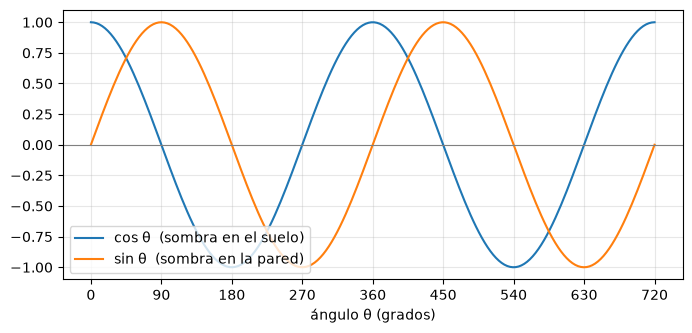

In [13]:
plt.figure(figsize=(8, 3.5))
plt.plot(np.degrees(angulos), np.cos(angulos), label="cos θ  (sombra en el suelo)")
plt.plot(np.degrees(angulos), np.sin(angulos), label="sin θ  (sombra en la pared)")
plt.axhline(0, color="gray", lw=0.8)
plt.xlabel("ángulo θ (grados)")
plt.xticks(range(0, 721, 90))
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

Dos **ondas** que suben y bajan entre −1 y 1, repitiéndose cada 360° (cada vuelta). Las dos son la **misma** forma; solo están **desplazadas** un cuarto de vuelta (90°) una respecto de la otra: el coseno va "un cuarto de vuelta por delante" del seno.

Guárdate esta imagen, porque es **muy** de robots. Andar es un movimiento que **se repite** (NB35: "paso, paso, paso"). La cadera va adelante y atrás, adelante y atrás... como una onda. Y la rodilla también, pero no al mismo tiempo: va **desplazada**. Al final del notebook fabricaremos un "paso" con dos ondas así.


## 6 · Brazos de cualquier largo

Hasta ahora el brazo medía 1. ¿Y si mide **L**? Las sombras crecen en proporción: un brazo el doble de largo hace sombras el doble de largas. Así que la punta de un brazo de largo L, girado un ángulo θ desde la horizontal, está en:

```
   x  =  L × cos θ      (cuánto a la derecha)
   y  =  L × sin θ      (cuánto hacia arriba)
```

Un ejemplo de la vida real: una **escalera** de 3 metros apoyada en la pared, formando **60°** con el suelo. ¿A qué altura llega? ¿A qué distancia de la pared está su pie?


In [14]:
largo = 3
angulo = math.radians(60)
print("altura que alcanza:", round(largo * math.sin(angulo), 2), "m")
print("distancia a la pared:", round(largo * math.cos(angulo), 2), "m")

altura que alcanza: 2.6 m
distancia a la pared: 1.5 m


Llega a **2,6 m** de altura, con el pie a **1,5 m** de la pared. Fíjate: cos 60° = 0,5 exactamente, así que la sombra en el suelo es **la mitad** de la escalera.


## 7 · Medir desde la vertical: piernas y palos

En robótica hay un detalle importante. Los ángulos de una **pierna** o de un **palo de escoba** no se suelen medir desde la horizontal, como la escalera, sino desde la **vertical**: la pierna "recta", colgando hacia abajo, es el ángulo **0**. Y lo mismo la inclinación del palo (NB11) o del torso de Hopper: 0 es "recto".

Si medimos desde la vertical, los papeles del seno y el coseno **se intercambian**. Mira un palo de largo L inclinado un ángulo θ desde la vertical:

```
                    ● punta
                   ╱│
                  ╱ │
               L ╱  │  L × cos θ   (altura de la punta)
                ╱ θ │
               ●────┘
              base   L × sin θ    (cuánto se ha ido hacia el lado)
```

```
   hacia el lado  =  L × sin θ
   hacia arriba   =  L × cos θ
```

Tiene sentido: con el palo recto (θ = 0), sin 0 = 0 (no se va nada hacia el lado) y cos 0 = 1 (toda su longitud es altura). Y si se inclina mucho, se va hacia el lado y pierde altura.


Con esto podemos entender de verdad la condición de "sano" de Hopper. Su torso mide unos 0,4 m. Si se inclina 0,2 radianes (el límite), ¿cuánto se desplaza su parte de arriba hacia el lado? ¿Cuánta altura pierde?

In [15]:
largo_torso = 0.4
inclinacion = 0.2                                     # ya está en radianes
print("hacia el lado:", round(largo_torso * math.sin(inclinacion), 3), "m")
print("altura:       ", round(largo_torso * math.cos(inclinacion), 3), "m de", largo_torso)

hacia el lado: 0.079 m
altura:        0.392 m de 0.4


Se desplaza unos **8 centímetros** y apenas pierde altura (menos de 1 cm). Con ángulos pequeños pasa siempre: el desplazamiento hacia el lado es casi igual al propio ángulo por el largo (0,4 × 0,2 = 0,08), y la altura casi no cambia. Es la razón por la que el palo de escoba del NB11 podía usar fórmulas tan sencillas: con inclinaciones pequeñas, sin θ ≈ θ. Lo aprovecharemos en el NB37.


## 8 · Pitágoras: la sombra en el suelo y la sombra en la pared

Una propiedad que conviene conocer. La punta del brazo de largo 1 está siempre a distancia 1 del centro. Las dos sombras forman un **triángulo rectángulo** (con una esquina de 90°) cuyo lado largo, el brazo, mide 1.

Hace 2.500 años, **Pitágoras** (o alguien de su escuela) demostró que en cualquier triángulo rectángulo, si los lados cortos miden **a** y **b** y el largo mide **c**:

```
   a²  +  b²  =  c²
```

Aplicado a nuestras sombras (a = cos θ, b = sin θ, c = 1):

```
   cos²θ  +  sin²θ  =  1        para CUALQUIER ángulo θ
```

(cos²θ significa "el coseno de θ, elevado al cuadrado".) Comprobémoslo con un ángulo cualquiera:


In [16]:
theta = 1.234
print(math.cos(theta) ** 2 + math.sin(theta) ** 2)

0.9999999999999999


1 (o 0,9999999999999999, por el ruido de decimales). Y Pitágoras sirve para mucho más: calcula la **distancia** entre dos puntos cualesquiera. Si un punto está 3 m a la derecha y 4 m arriba de otro, la distancia en línea recta es √(3² + 4²) = √25 = **5 m**. Es la "longitud de una flecha" del NB12, la misma cuenta.


## 9 · El camino de vuelta: de la posición al ángulo

Hasta ahora: **ángulo → posición**. Muchas veces hace falta lo contrario: sé **dónde** está algo y quiero saber **en qué dirección** está. Por ejemplo: el robot ve una pelota 1 m a la derecha y 1 m por delante; ¿cuánto tiene que girar para mirarla?

Para eso existe la función **`math.atan2(y, x)`** ("arcotangente de dos argumentos"): le das las dos coordenadas de un punto, **primero la y, luego la x** (¡ojo con el orden!), y te devuelve el **ángulo** de la flecha que va del centro a ese punto, en radianes.


In [17]:
print(math.degrees(math.atan2(1, 1)))

45.0


**45°**: el punto (1, 1) está justo en diagonal. Otro, a la izquierda y arriba:

In [18]:
print(math.degrees(math.atan2(1, -1)))

135.0


**135°**: tres cuartos del camino hasta la izquierda del todo. Correcto.

¿Por qué "atan**2**"? Porque existe una versión antigua, `math.atan`, que solo recibe **un** número: la división y ÷ x. Y ahí está el problema: para el punto (1, 1) la división da 1 ÷ 1 = 1, y para el punto (−1, −1), que está en el lado **opuesto**, da (−1) ÷ (−1) = 1 también. ¡No puede distinguirlos! Mira:


In [19]:
print(math.degrees(math.atan(1 / -1)))

-45.0


**−45°** para el punto (−1, 1), cuando la respuesta buena era 135°: apunta en la dirección **contraria**. Como `atan2` recibe la y y la x **por separado**, sabe en qué cuarto del círculo está el punto y nunca se equivoca. Regla de profesional: **usa siempre `atan2`**.


## 10 · ¿Dónde está el pie? Cinemática directa

Ya tenemos todas las herramientas. Vamos a por la pregunta del principio, con la pierna de **Hopper**. Las medidas, sacadas de su "plano" (NB01) de MuJoCo:

- La **cadera** está a **1,05 m** del suelo cuando el robot está de pie y recto.
- El **muslo** mide **0,45 m** (de la cadera a la rodilla).
- La **pierna** mide **0,50 m** (de la rodilla al tobillo).

Y los ángulos se miden **desde la vertical** (pierna colgando recta = 0). En el Hopper de MuJoCo, un ángulo **positivo** mueve el tramo **hacia delante** (hacia donde avanza el robot) y uno **negativo**, hacia atrás.

Ahora, la idea clave. Mira tu propia pierna: si mueves la **cadera**, se mueve **todo** lo que cuelga de ella (muslo, rodilla, pierna, pie). Si doblas la **rodilla**, el muslo se queda quieto, pero la parte de abajo gira **además** de lo que ya giró la cadera. Por eso:

> El ángulo **de la rodilla** se mide **respecto del muslo**, no respecto de la vertical. La dirección de la pierna, respecto de la vertical, es la **suma**: ángulo de cadera + ángulo de rodilla.

```
         ● cadera
          ╲  θ cadera (respecto de la vertical)
           ╲  muslo
            ● rodilla
            │ ╲
            │  ╲ θ rodilla (respecto del muslo)
            │   ╲  pierna: su dirección total es θ cadera + θ rodilla
                 ● tobillo
```


Con eso, la receta para encontrar el tobillo es ir **tramo a tramo**, como siguiendo una cadena:

1. Empieza en la **cadera**: (0, 1,05).
2. Avanza por el **muslo**, con dirección θ_cadera: la rodilla está 0,45 × sin(θ_cadera) hacia delante y 0,45 × cos(θ_cadera) más **abajo** que la cadera (cuelga hacia abajo, así que la altura **se resta**).
3. Avanza por la **pierna**, con dirección θ_cadera + θ_rodilla: el tobillo está 0,50 × sin(θ_cadera + θ_rodilla) hacia delante y 0,50 × cos(θ_cadera + θ_rodilla) más abajo que la rodilla.

A esto se le llama **cinemática directa** (*forward kinematics*): de los ángulos de las articulaciones, a las posiciones de las piezas. "Cinemática" viene del griego *kínema*, "movimiento": es la parte de la física que describe **cómo** se mueven las cosas, sin preguntarse por las fuerzas.

Primero, las medidas:


In [20]:
ALTURA_CADERA = 1.05
MUSLO = 0.45
PIERNA = 0.50

Y la receta, como función de Python (NB10), paso a paso:

In [21]:
def donde_esta_el_tobillo(cadera, rodilla):
    # 1. empezamos en la cadera
    x, y = 0.0, ALTURA_CADERA
    # 2. bajamos por el muslo
    x = x + MUSLO * math.sin(cadera)
    y = y - MUSLO * math.cos(cadera)
    # 3. bajamos por la pierna: su dirección es la SUMA de los dos ángulos
    x = x + PIERNA * math.sin(cadera + rodilla)
    y = y - PIERNA * math.cos(cadera + rodilla)
    return x, y

Probémosla primero con la pierna **recta** (los dos ángulos a 0). El tobillo debería estar justo debajo de la cadera, a 1,05 − 0,45 − 0,50 = 0,10 m del suelo:

In [22]:
print(donde_esta_el_tobillo(0, 0))

(0.0, 0.10000000000000009)


(0, 0,1): justo debajo, a 10 cm del suelo (el pie tiene su grosor). El 0,10000000000000009 es el ruido de decimales del NB06. Ahora una postura de verdad: la cadera **hacia atrás** 0,5 radianes y la rodilla doblada otros 0,8 radianes **hacia atrás**:

In [23]:
x, y = donde_esta_el_tobillo(-0.5, -0.8)
print(f"tobillo en x = {x:.4f} m, altura = {y:.4f} m")

tobillo en x = -0.6975 m, altura = 0.5213 m


El tobillo ha quedado **70 cm por detrás** de la cadera y a **52 cm** del suelo: la pierna recogida hacia atrás, como cuando levantas el pie para dar una patada a un balón.

### ¿Nos lo creemos? Preguntémosle a MuJoCo

Hemos hecho las cuentas a mano. Ahora, el examen de verdad: ponemos al Hopper de MuJoCo **exactamente** en esa postura y le preguntamos al simulador dónde ha quedado su tobillo.

En MuJoCo, la postura entera del robot está en una lista llamada **`qpos`** (*q* es la letra que usan los ingenieros para las posiciones de las articulaciones; *pos* de "posición"). En Hopper tiene 6 números, por este orden: posición hacia delante, altura del torso, inclinación del torso, cadera, rodilla y tobillo.


In [24]:
import os
os.environ["MUJOCO_GL"] = "egl"
import gymnasium as gym
import mujoco

hopper = gym.make("Hopper-v5")
hopper.reset(seed=0)
modelo = hopper.unwrapped.model         # el plano (NB35)
datos = hopper.unwrapped.data           # el estado actual: posiciones, velocidades...

`datos` es el **estado** del simulador en este instante (NB35 usaba `model`, el plano; `data` es lo que cambia mientras se mueve). Colocamos la postura en `qpos`: x = 0, torso a 1,25 m de altura y recto, cadera −0,5, rodilla −0,8, tobillo 0:

In [25]:
datos.qpos[:] = [0.0, 1.25, 0.0, -0.5, -0.8, 0.0]
mujoco.mj_forward(modelo, datos)

`mujoco.mj_forward` le pide a MuJoCo que **recalcule** dónde está cada pieza a partir de `qpos`... con su propia cinemática directa, ¡la misma idea que acabamos de programar! (sin avanzar el tiempo: solo coloca las piezas). Ahora le preguntamos dónde está la **bisagra del tobillo** (`foot_joint`). `xanchor` es el punto del mundo donde está "anclada" una bisagra, con 3 coordenadas: x (delante), y (de lado; en un robot plano siempre 0) y z (altura):

In [26]:
tobillo_mujoco = datos.joint("foot_joint").xanchor
print("MuJoCo dice:   x =", tobillo_mujoco[0].round(4), "| altura =", tobillo_mujoco[2].round(4))
print("Nosotros:      x =", round(x, 4), "| altura =", round(y, 4))

MuJoCo dice:   x = -0.6975 | altura = 0.5213
Nosotros:      x = -0.6975 | altura = 0.5213


**Iguales**, hasta el cuarto decimal. Tu función de cinco líneas hace exactamente lo mismo que el simulador profesional. No hay magia en MuJoCo: dentro hay senos, cosenos y sumas de ángulos, para todas las piezas de todos los robots.

Y ahora lo vemos todo **dibujado**. Una función que dibuja la pierna (cadera → rodilla → tobillo) para una postura:


In [27]:
def dibujar_pierna(cadera, rodilla, color):
    rodilla_x = MUSLO * math.sin(cadera)
    rodilla_y = ALTURA_CADERA - MUSLO * math.cos(cadera)
    tobillo_x, tobillo_y = donde_esta_el_tobillo(cadera, rodilla)
    plt.plot([0, rodilla_x, tobillo_x], [ALTURA_CADERA, rodilla_y, tobillo_y], "o-", color=color, lw=3,
             label=f"cadera {cadera:+.1f}, rodilla {rodilla:+.1f}")

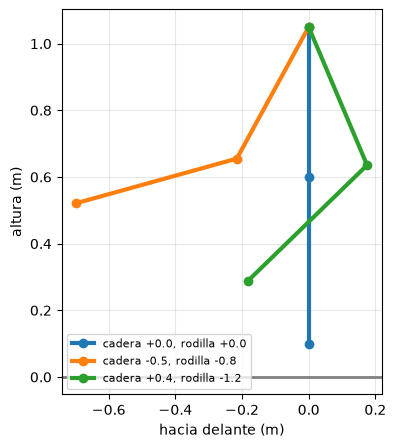

In [28]:
plt.figure(figsize=(5, 5))
dibujar_pierna(0.0, 0.0, "tab:blue")
dibujar_pierna(-0.5, -0.8, "tab:orange")
dibujar_pierna(0.4, -1.2, "tab:green")
plt.axhline(0, color="gray", lw=2)                      # el suelo
plt.gca().set_aspect("equal")                           # que 1 m mida lo mismo en los dos ejes
plt.xlabel("hacia delante (m)")
plt.ylabel("altura (m)")
plt.legend(loc="lower left", fontsize=8)
plt.grid(alpha=0.3)
plt.show()

(`set_aspect("equal")` hace que un metro mida lo mismo en horizontal y en vertical, para que la pierna no salga deformada.)

Tres posturas: la **azul**, recta; la **naranja**, la que comprobamos con MuJoCo, recogida hacia atrás; la **verde**, con el muslo hacia delante (+0,4) y la rodilla muy doblada hacia atrás (−1,2), como al subir un escalón. Fíjate en la verde: aunque la rodilla está muy doblada, el tobillo queda solo **18 cm** por detrás de la cadera, porque el muslo va hacia delante y la pierna vuelve hacia atrás: los dos giros se compensan en parte. La dirección de la pierna es 0,4 + (−1,2) = −0,8: la suma.


## 11 · Un paso con dos ondas

Para terminar, juntemos las dos grandes ideas de hoy: las **ondas** (sección 5) y la **cinemática directa** (sección 10).

Si movemos la cadera adelante y atrás como una onda, y la rodilla también, el pie dibujará algún tipo de recorrido. Probemos:

- **Cadera**: 0,4 × sin(fase). Va de −0,4 a +0,4 radianes (unos ±23°) y vuelve.
- **Rodilla**: −0,5 + 0,5 × sin(fase − 1,5). Siempre doblada hacia atrás (entre −1 y 0) y **retrasada** casi un cuarto de vuelta (1,5 radianes) respecto de la cadera.

La **fase** es "en qué punto del ciclo estamos", un ángulo que va de 0 a 2π (una vuelta del ciclo = un paso completo). Como NumPy trabaja con listas enteras, calculamos el ciclo completo de golpe:


In [29]:
fase = np.linspace(0, 2 * np.pi, 100)
cadera = 0.4 * np.sin(fase)
rodilla = -0.5 + 0.5 * np.sin(fase - 1.5)

Y la cinemática directa, la misma de antes pero con `np.sin`/`np.cos` para que funcione con las 100 posturas a la vez:

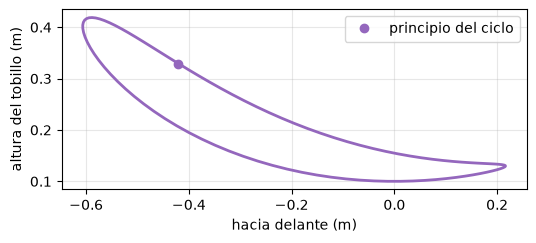

In [30]:
pie_x = MUSLO * np.sin(cadera) + PIERNA * np.sin(cadera + rodilla)
pie_y = ALTURA_CADERA - MUSLO * np.cos(cadera) - PIERNA * np.cos(cadera + rodilla)

plt.figure(figsize=(6, 3.5))
plt.plot(pie_x, pie_y, color="tab:purple", lw=2)
plt.plot(pie_x[0], pie_y[0], "o", color="tab:purple", label="principio del ciclo")
plt.gca().set_aspect("equal")
plt.xlabel("hacia delante (m)")
plt.ylabel("altura del tobillo (m)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

¡El tobillo dibuja un **lazo**! En una parte del ciclo va bajo, a 10 cm del suelo (con la pierna estirada), y en la otra sube hasta unos **42 cm**, sobre todo **por detrás** del cuerpo (como el talón que se levanta hacia atrás al correr). Y lo recorre en un sentido muy concreto: cuando va **abajo**, se mueve **hacia atrás**, y cuando va **arriba**, vuelve **hacia delante**. Eso es, en esencia, un paso: el pie va por abajo empujando el suelo hacia atrás (y el suelo empuja al robot hacia delante, NB35: la fase de **apoyo**) y vuelve por arriba, levantado, para no tropezar (la fase de **vuelo**).

Con solo dos ondas y su **desfase** (los 1,5 radianes de retraso de la rodilla), has fabricado el patrón básico de andar. Muchos robots reales usan exactamente esta idea: unos generadores de ondas que marcan el ritmo de cada articulación (se llaman **generadores centrales de patrones**, *central pattern generators*, porque imitan unos circuitos de neuronas de la médula espinal de los animales que hacen lo mismo). Y muchas políticas de RL para robots reciben la fase como una observación más, para que les sea más fácil aprender el ritmo. Prueba a cambiar el desfase en el ejercicio E6.


## 12 · Resumen de la lección

1. Un **ángulo** mide un **giro** alrededor de un punto fijo, desde una posición de partida (el cero). No depende del largo.
2. **Grados**: 360 por vuelta (herencia babilónica). **Radianes**: se mide con el radio; una vuelta = **2π ≈ 6,28** rad; 1 rad ≈ 57,3°. Los simuladores usan radianes. `math.radians`/`math.degrees` traducen.
3. **π ≈ 3,14** = perímetro ÷ diámetro de cualquier círculo. Con radianes: **arco = radio × ángulo**.
4. **cos θ** y **sin θ**: las "sombras" (coordenadas) de la punta de un brazo de largo 1 girado θ: cuánto a la derecha y cuánto arriba. **Ojo:** `math.sin` quiere radianes; `math.sin(90)` da un número equivocado sin avisar.
5. Dibujados, el seno y el coseno son **ondas** desplazadas un cuarto de vuelta. Andar es cíclico como una onda.
6. Brazo de largo L desde la horizontal: x = L·cos θ, y = L·sin θ. Desde la **vertical** (piernas, palos, torsos): hacia el lado L·sin θ, altura L·cos θ.
7. **Pitágoras**: a² + b² = c²; cos²θ + sin²θ = 1; distancia entre puntos.
8. **`atan2(y, x)`**: de la posición al ángulo, sin confundirse de cuarto del círculo (nunca `atan`).
9. **Cinemática directa**: de los ángulos a las posiciones, tramo a tramo; **los ángulos se suman** a lo largo de la cadena. Nuestra función coincide con MuJoCo (`qpos`, `mj_forward`, `xanchor`).
10. Dos ondas **desfasadas** en cadera y rodilla hacen que el pie dibuje un lazo: el patrón básico de un paso.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Ángulo** | Cuánto ha girado algo alrededor de un punto fijo. |
| **Grado (°)** | Unidad de ángulo: 360 por vuelta. |
| **π (pi)** | 3,14159...: perímetro ÷ diámetro de cualquier círculo. |
| **Radio / diámetro / perímetro** | Del centro al borde / de lado a lado / lo que mide el borde. |
| **Radián** | Unidad de ángulo medida con el radio: 2π por vuelta. |
| **Arco** | Trozo de borde que recorre un punto al girar: radio × ángulo. |
| **Coseno (cos) / seno (sin)** | Coordenadas horizontal / vertical de la punta de un brazo de largo 1 girado un ángulo. |
| **Onda** | Curva que sube y baja repitiéndose, como el seno al girar sin parar. |
| **Desfase** | Cuánto va adelantada una onda respecto de otra. |
| **Pitágoras** | En un triángulo rectángulo, a² + b² = c². |
| **`atan2(y, x)`** | El ángulo de la flecha que va al punto (x, y). |
| **Cinemática / cinemática directa** | Física del movimiento sin fuerzas / de los ángulos a las posiciones. |
| **`qpos`** | En MuJoCo, la lista con la postura completa del robot. |
| **`mj_forward`** | Recalcula dónde está cada pieza a partir de `qpos`. |
| **`xanchor`** | Punto del mundo donde está una bisagra. |
| **Fase** | En qué punto de un ciclo (de un paso) estamos. |
| **Generador central de patrones (CPG)** | Generador de ondas que marca el ritmo de las articulaciones. |


## 13 · Ejercicios

**E1.** Pasa a radianes: 30°, 180°, 270°. Y a grados: 0,5 rad, 3 rad. Primero piénsalo con la tabla de la sección 4, luego compruébalo con Python.

**E2.** Una rueda de 0,25 m de radio gira 3 radianes sin resbalar. ¿Cuánto avanza el robot? ¿Y si gira 90°?

**E3.** Sin calcular, solo imaginando el brazo que gira: ¿cuál es el signo (positivo o negativo) de cos 120° y de sin 120°? ¿Y de cos 200° y sin 200°? Compruébalo con Python.

**E4.** Walker2d se inclina 1 radián (su límite). Si su torso mide 0,4 m, ¿cuánto se desplaza la parte de arriba del torso hacia delante y cuánta altura tiene ahora el torso? Compáralo con el Hopper de la sección 7.

**E5.** Un robot está en el origen mirando hacia la derecha (ángulo 0). Ve una pelota en el punto (−2, −2). ¿Cuánto tiene que girar para mirarla? ¿Qué daría `math.atan(-2 / -2)` y por qué está mal?

**E6.** En la sección 11, cambia el desfase de la rodilla de −1,5 a **+1,5** (es decir, `np.sin(fase + 1.5)`) y dibuja el recorrido del tobillo. ¿Qué cambia? ¿Por qué ese paso sería peor para andar hacia delante?

**E7.** **Reto.** Añade el **pie** a la cinemática directa. En Hopper, la bisagra del tobillo tiene delante un pie de 0,26 m que, con el tobillo a 0, apunta **horizontal hacia delante**. Escribe una función que, dados los tres ángulos (cadera, rodilla, tobillo), devuelva dónde está la **punta** del pie. Pista: el pie apunta "a 90° de la pierna"; su dirección total, medida desde la vertical, es cadera + rodilla + tobillo + π/2.


<details>
<summary>▶ Solución E1</summary>

De grados a radianes: 30° es la tercera parte de 90° (π/2), así que π/6 ≈ **0,524**; 180° = π ≈ **3,142**; 270° = tres cuartos de vuelta = 3π/2 ≈ **4,712**. De radianes a grados: 0,5 rad ≈ 0,5 × 57,3 ≈ **28,6°**; 3 rad ≈ **171,9°** (casi media vuelta, que sería π ≈ 3,14).

```python
for grados in [30, 180, 270]:
    print(grados, "°  →", round(math.radians(grados), 3), "rad")
for rad in [0.5, 3]:
    print(rad, "rad  →", round(math.degrees(rad), 1), "°")
```
</details>

<details>
<summary>▶ Solución E2</summary>

Arco = radio × ángulo (en radianes): 0,25 × 3 = **0,75 m**. Para 90° hay que pasar antes a radianes: 90° = π/2 ≈ 1,571 rad, así que 0,25 × 1,571 ≈ **0,39 m**. Si hubieras hecho 0,25 × 90 = 22,5 m, el error de unidades te habría dado un robot que avanza ¡22 metros con un cuarto de vuelta de rueda!

```python
print(0.25 * 3, round(0.25 * math.radians(90), 3))
```
</details>

<details>
<summary>▶ Solución E3</summary>

A **120°** el brazo ha pasado de la vertical (90°) hacia la izquierda: está a la **izquierda** (cos **negativo**) y **arriba** (sin **positivo**). A **200°** ha pasado de la izquierda del todo (180°) hacia abajo: está a la **izquierda** (cos **negativo**) y un poco **abajo** (sin **negativo**).

```python
for g in [120, 200]:
    print(g, round(math.cos(math.radians(g)), 3), round(math.sin(math.radians(g)), 3))
```

Da cos 120° = −0,5, sin 120° = 0,866; cos 200° = −0,94, sin 200° = −0,342.
</details>

<details>
<summary>▶ Solución E4</summary>

Medido desde la vertical: hacia delante L·sin θ = 0,4 × sin 1 ≈ **0,337 m**; altura L·cos θ = 0,4 × cos 1 ≈ **0,216 m** (de 0,4). Con 1 radián el torso se desplaza 34 cm y pierde casi la **mitad** de su altura: está muy tumbado. Hopper, con su límite de 0,2, solo se desplazaba 8 cm y no perdía casi nada. Aquí ya no vale el truco de "sin θ ≈ θ" de los ángulos pequeños: sería 0,4 × 1 = 0,4 m, bastante más que los 0,337 de verdad.

```python
print(round(0.4 * math.sin(1), 3), round(0.4 * math.cos(1), 3))
```
</details>

<details>
<summary>▶ Solución E5</summary>

```python
print(math.degrees(math.atan2(-2, -2)))     # -135.0
print(math.degrees(math.atan(-2 / -2)))     # 45.0  ← ¡al revés!
```

`atan2` da **−135°**: girar 135° a favor de las agujas del reloj (o, lo que es lo mismo, 225° en contra), hacia la izquierda y abajo, donde está la pelota. `atan` recibe solo la división (−2) ÷ (−2) = 1, la misma que para el punto (2, 2), y responde **45°**: el robot se giraría hacia la derecha y arriba, justo en la dirección **opuesta** a la pelota.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
rodilla = -0.5 + 0.5 * np.sin(fase + 1.5)
pie_x = MUSLO * np.sin(cadera) + PIERNA * np.sin(cadera + rodilla)
pie_y = ALTURA_CADERA - MUSLO * np.cos(cadera) - PIERNA * np.cos(cadera + rodilla)
plt.plot(pie_x, pie_y); plt.gca().set_aspect("equal"); plt.show()
```

El dibujo es igual, pero el lazo se recorre **al revés**: ahora el pie va **abajo** mientras se mueve **hacia delante**, y sube mientras vuelve hacia atrás. Es decir, el pie se apoya justo cuando avanza (arrastrándose por el suelo y frenando) y se levanta justo cuando debería empujar. Este "paso" empujaría el robot **hacia atrás**. El desfase no es un detalle: decide hacia dónde se anda.
</details>

<details>
<summary>▶ Solución E7</summary>

```python
PIE = 0.26

def donde_esta_la_punta_del_pie(cadera, rodilla, tobillo):
    x, y = donde_esta_el_tobillo(cadera, rodilla)
    direccion = cadera + rodilla + tobillo + math.pi / 2     # el pie va "a 90°" de la pierna
    x = x + PIE * math.sin(direccion)
    y = y - PIE * math.cos(direccion)
    return x, y

print(donde_esta_la_punta_del_pie(0, 0, 0))
```

Con todo a 0 da (0,26, 0,10): la punta está 26 cm por delante del tobillo y a su misma altura (cos(π/2) = 0, así que no sube ni baja), es decir, el pie horizontal. Es la misma regla de siempre: un tramo más en la cadena, y su ángulo es la suma de todos los anteriores. Puedes comprobarlo con MuJoCo: la punta del pie no es una bisagra, pero `datos.geom("foot_geom")` te da el centro de la cápsula del pie, que debe quedar a mitad de camino entre el talón y la punta.
</details>


## 14 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Hoy has aprendido a **describir** la postura del robot. En el **NB37** pasamos a lo que la **cambia**: las fuerzas. Qué es exactamente una fuerza, qué hace la masa, qué es el **par** que producen los motores (por qué el multiplicador de Hopper importa tanto), y de dónde salía aquella fórmula del palo de escoba del NB11, "aceleración = 10 × inclinación". Con el seno de hoy, la vas a poder deducir tú.
